instalando e importando bilbiotecas

In [14]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

Ordenação das imagens\
Uso de imagens em .dcm para melhor resolução e informações\
Conversão para unidades de hounsfield, o que facilita a delimitação de osso, tecido mole, ar e água\
É uma unidade padrão usada em imagens médicas

Iniciando leitura dos arquivos...
Total de arquivos DICOM encontrados: 91
Ordenação realizada com sucesso
------------------------------
Volume carregado com sucesso!
Dimensões (Fatias, Y, X): (91, 512, 512)
Tipo de dado: float64
Valor Mínimo (HU): -2048.0
Valor Máximo (HU): 5449.0
------------------------------


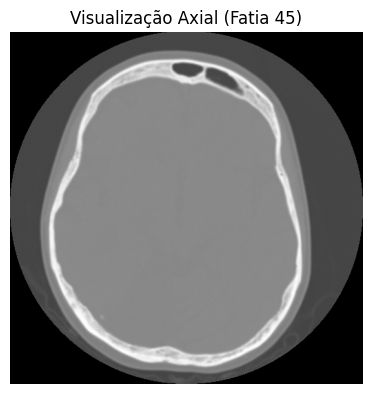

In [15]:
dataset_path = 'cancer'

# Lê uma pasta de arquivos DICOM, ordena espacialmente e retorna
# o volume 3D como um array numpy e a lista de metadados.
def load_dicom_volume(path_to_dicom):

    # Lista arquivos .dcm
    dicom_files = [os.path.join(path_to_dicom, f) for f in os.listdir(path_to_dicom) if f.endswith('.dcm')]

    print(f"Total de arquivos DICOM encontrados: {len(dicom_files)}")

    # Carrega os metadados de cada arquivo
    slices = [pydicom.dcmread(f) for f in dicom_files]

    # Ordena as fatias pela posição da imagem no eixo Z
    slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))
    print("Ordenação realizada com sucesso")

    # Cria o volume 3D empilhando os arrays de pixels
    volume_3d = np.stack([s.pixel_array for s in slices])
    
    # Conversão para Unidades Hounsfield (HU), que é a escala padrão para imagens médicas de tomografias.
    # Pixel_HU = Pixel_Bruto * Slope + Intercept
    # Isso corrige o brilho para que 'Osso' tenha sempre o mesmo valor numérico
    volume_3d = volume_3d.astype(np.float64)
    
    # Pega os valores de calibração da primeira fatia (assumindo constantes para o scan)
    intercept = slices[0].RescaleIntercept
    slope = slices[0].RescaleSlope
    
    if slope != 1:
        volume_3d = slope * volume_3d.astype(np.float64)
        volume_3d = volume_3d.astype(np.int16)
        
    volume_3d += np.int16(intercept)
    
    return volume_3d, slices

try:
    # Chama a função de carregamento
    print("Iniciando leitura dos arquivos...")
    volume, metadata_slices = load_dicom_volume(dataset_path)

    # Exibe informações sobre o volume criado
    print("-" * 30)
    print(f"Volume carregado com sucesso!")
    print(f"Dimensões (Fatias, Y, X): {volume.shape}")
    print(f"Tipo de dado: {volume.dtype}")
    print(f"Valor Mínimo (HU): {np.min(volume)}")
    print(f"Valor Máximo (HU): {np.max(volume)}")
    print("-" * 30)

    # Plota a fatia do meio para garantir que não está corrompido
    middle_index = volume.shape[0] // 2
    
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.imshow(volume[middle_index], cmap='gray')
    plt.title(f"Visualização Axial (Fatia {middle_index})")
    plt.axis('off')
    
    plt.show()

except Exception as e:
    print(f"Ocorreu um erro: {e}")

Utilização do np.where para identificar osso\
Reconstrução de uma imagem reduzida para ver se funcionou sem demorar muito

Aplicando limiar de 400 HU...
Máscara binária criada. Shape: (91, 512, 512)
Total de voxels de osso detectados: 1582839
Segmentação via np.where concluída com sucesso.


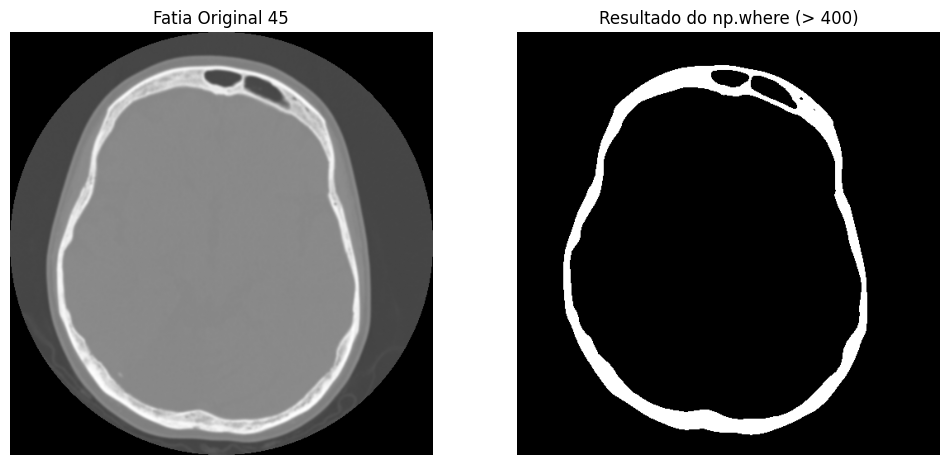

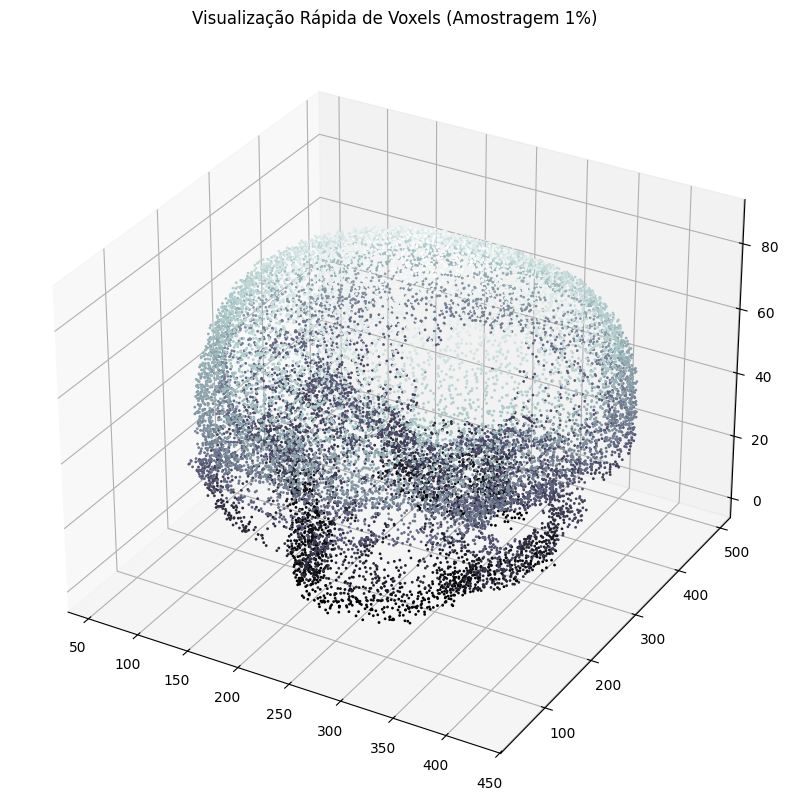

In [16]:
# Limiar para separar osso de tecido mole
# Em unidades Hounsfield (HU), osso compacto é > 300~400
THRESHOLD_VALUE = 400

def segment_with_where(vol_data, threshold):
    
    # Usa np.where para binarizar o volume e extrair coordenadas
    # Representação por voxels
    
    print(f"Aplicando limiar de {threshold} HU...")

    # Criação de máscara binária
    binary_mask = np.where(vol_data > threshold, 1, 0)
    
    print(f"Máscara binária criada. Shape: {binary_mask.shape}")

    # 2. Extração de coordenadas dos voxels de osso usando np.where
    z_coords, y_coords, x_coords = np.where(binary_mask == 1)
    
    print(f"Total de voxels de osso detectados: {len(z_coords)}")
    
    return binary_mask, (z_coords, y_coords, x_coords)

try:
    # Executa a segmentação
    mask_3d, voxel_coords = segment_with_where(volume, THRESHOLD_VALUE)
    
    print("Segmentação via np.where concluída com sucesso.")

    # Visualização rápida para verificar o resultado da segmentação
    
    # Visualização de fatia intermediária para verificar a segmentação
    mid_slice_idx = volume.shape[0] // 2
    
    plt.figure(figsize=(12, 6))
    
    # Esquerda: Imagem original (tons de cinza)
    plt.subplot(1, 2, 1)
    plt.imshow(volume[mid_slice_idx], cmap='gray')
    plt.title(f"Fatia Original {mid_slice_idx}")
    plt.axis('off')
    
    # Direita: Resultado do np.where (preto ou branco)
    plt.subplot(1, 2, 2)
    plt.imshow(mask_3d[mid_slice_idx], cmap='gray')
    plt.title(f"Resultado do np.where (> {THRESHOLD_VALUE})")
    plt.axis('off')
    
    plt.show()
    
    # Vizualização com 1% dos pontos
    skip = 100
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Plota os pontos (z, y, x)
    # Troca eixos y e z para figura ficar orientada da maneira correta
    ax.scatter(voxel_coords[2][::skip], voxel_coords[1][::skip], voxel_coords[0][::skip], 
               s=1, c=voxel_coords[0][::skip], cmap='bone', alpha=1)
    
    ax.set_title("Visualização Rápida de Voxels (Amostragem 1%)")
    plt.show()

except Exception as e:
    print(f"Ocorreu um erro: {e}")

Utilizando PLotly para reconstrução com isosuperfícies

In [17]:
# Valores que melhor renderizaram a imagem (tentativa e erro)
pixel_spacing = 1.0
slice_thickness = 3.0
bone_threshold = 400

# Fator de redução, se deixar 1 trava o navegador
step = 2

# Redução de volume para performance
vol_small = volume[::step, ::step, ::step]

# Cria as grades de coordenadas para o volume reduzido
# O np.mgrid cria índices para cada voxel (Z, Y, X)
dim_z, dim_y, dim_x = vol_small.shape
Z, Y, X = np.mgrid[:dim_z, :dim_y, :dim_x]

# Aplicação da escala
X = X.flatten() * step * pixel_spacing
Y = Y.flatten() * step * pixel_spacing
Z = Z.flatten() * step * slice_thickness
Values = vol_small.flatten()

print(f"Gerando Isosuperfície nativa com {len(Values)} voxels...")

#Visualização usando Plotly Isosurface
fig = go.Figure(data=[
    go.Isosurface(
        x=X,
        y=Y,
        z=Z,
        value=Values,
        isomin=bone_threshold,
        isomax=bone_threshold,
        surface_count=1,       
        caps=dict(x_show=False, y_show=False, z_show=False), 
        opacity=1.0,
        colorscale=[[0, 'ivory'], [1, 'ivory']], # Gambiarra para usar uma cor sólida parecida com osso
        lighting=dict(ambient=0.4, diffuse=0.5, roughness=0.1, specular=0.4), # Iluminação para realçar as curvas e reentrâncias do crânio
        lightposition=dict(x=100, y=100, z=500)
    )
])

# Configurações de layout e espaço de coordenadas
fig.update_layout(
    title="Reconstrução 3D",
    scene=dict(
        xaxis_title='X (mm)',
        yaxis_title='Y (mm)',
        zaxis_title='Z (Altura mm)',
        aspectmode='data'
    ),
    width=800, height=800
)

# Renderiza no navegador
fig.show(renderer="browser")

Gerando Isosuperfície nativa com 3014656 voxels...


[2] Sandbox: CanCreateUserNamespace() clone() failure: EPERM
Gtk-Message: 23:47:33.839: Failed to load module "canberra-gtk-module"
Gtk-Message: 23:47:33.846: Failed to load module "canberra-gtk-module"


Usando PLotly para construção 3D com voxels

In [18]:
# --- CONFIGURAÇÃO ---
THRESHOLD = 400       
SKIP_RATE = 3 

def plot_voxels_depth(vol_data, threshold, skip=SKIP_RATE):
    print("Processando voxels...")
    z, y, x = np.where(vol_data > threshold)
    
    # Redução
    z_s = z[::skip]
    y_s = y[::skip]
    x_s = x[::skip]
    
    # Intensidades para coloração dos pontos
    intensities = vol_data[z_s, y_s, x_s]
    
    # Correção de Escala Física
    p_spacing, s_thick = 1.0, 3.0

    z_real = z_s * s_thick
    y_real = y_s * p_spacing
    x_real = x_s * p_spacing

    
    # Coloração por densidade baseado nas intensidades originais dos voxels
    color_data = intensities
    colorscale = 'gray'
    cmin, cmax = 400, 1500 # Aumentando contraste para destacar osso
    title_text = "Voxelização (Densidade Óssea Contrastada)"

    fig = go.Figure(data=[
        go.Scatter3d(
            x=x_real, y=y_real, z=z_real,
            mode='markers',
            marker=dict(
                size=3,              
                color=color_data,
                colorscale=colorscale, 
                cmin=cmin, cmax=cmax, # Define os limites de cor
                opacity=0.3,         
                symbol='square'      
            )
        )
    ])

    fig.update_layout(
        title=title_text,
        scene=dict(
            xaxis_title='X (mm)',
            yaxis_title='Y (mm)',
            zaxis_title='Z (Altura mm)',
            aspectmode='data',
            bgcolor='black',
            camera=dict(
                eye=dict(x=1.6, y=1.6, z=1.6) # Câmera afastada para melhor visualização
            )
        ),
        width=900, height=800,
        paper_bgcolor='black',
        font_color='white'
    )

    fig.show(renderer="browser")

try:
    plot_voxels_depth(volume, threshold=400, skip=SKIP_RATE)

except Exception as e:
    print(e)

Processando voxels...


[2] Sandbox: CanCreateUserNamespace() clone() failure: EPERM
Gtk-Message: 23:47:35.817: Failed to load module "canberra-gtk-module"
Gtk-Message: 23:47:35.824: Failed to load module "canberra-gtk-module"
